**Hidden Markov Model**

Paulo Yoshio Kuga

In this notebook, we are going to show how to train the HMM model with lissa.

In [1]:
#import libraries

import pandas as pd
from matplotlib import pyplot as plt
import numpy as np

import hmmlearn.hmm as hmm

import lissa as li

Firstly, we load the original data into data preparer. it arranges correctly the original data.

In [2]:
baseData = li.DataPreparer("../data","full_sensor_1h [old].csv")
list(baseData)

Pumps : #38
Runs: #57


['time',
 'ESP motor Current - phase A',
 'ESP motor Current - phase B',
 'ESP motor Current - phase C',
 'VSD power frequency',
 'ESP motor temperature',
 'ESP differential pressure',
 'ESP intake Pressure',
 'Water Cut @ 20degC - 1 atm',
 'ESP intake temperature',
 'ESP discharge pressure',
 'ESP discharge temperature sensor',
 'Choke Opening',
 'Well head pressure',
 'Well head Temperature',
 'Well aligned to Train A',
 'Well aligned to Train B',
 'ESP Motor Voltage',
 'ESP Vibration X',
 'ESP Vibration Y',
 'Well Run',
 'Well_down']

Next, a condensed failure spreadsheet is merge with base data.

In [3]:
entireData,pumpList = li.FailureMerge(baseData,"../data","respostas.csv") 
list(entireData)

['ESP motor Current - phase A',
 'ESP motor Current - phase B',
 'ESP motor Current - phase C',
 'VSD power frequency',
 'ESP motor temperature',
 'ESP differential pressure',
 'ESP intake Pressure',
 'Water Cut @ 20degC - 1 atm',
 'ESP intake temperature',
 'ESP discharge pressure',
 'ESP discharge temperature sensor',
 'Choke Opening',
 'Well head pressure',
 'Well head Temperature',
 'Well aligned to Train A',
 'Well aligned to Train B',
 'ESP Motor Voltage',
 'ESP Vibration X',
 'ESP Vibration Y',
 'Well Run',
 'Well_down',
 'Pump Info',
 'Failure Info',
 'Failure']

The data provided came with features that might be merged, combined or readequated. This function can be configured into source code, but currently, calculates the absolute of current phases and vibrations. 

In [4]:
entireData = li.FeatureCreation(entireData)
list(entireData)

['VSD power frequency',
 'ESP motor temperature',
 'ESP intake Pressure',
 'Water Cut @ 20degC - 1 atm',
 'ESP intake temperature',
 'ESP discharge pressure',
 'Choke Opening',
 'Well head pressure',
 'Well head Temperature',
 'Well aligned to Train A',
 'Well aligned to Train B',
 'ESP Motor Voltage',
 'Well Run',
 'Well_down',
 'Pump Info',
 'Failure Info',
 'Failure',
 'Current Mean',
 'ESP Vibration Module']

After this procedure, for each pump, the **modified** Z-score is applied.

In [5]:
totalData = li.ProcessData(pumpList,entireData,totalDataPath="../data/totalProcessedData.csv")
list(totalData)

/home/kuga/Área de trabalho/equinor-pc/operational/lissa_pack/src/lissa/processing.py:264: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  totalData = pd.concat([totalData,
/home/kuga/Área de trabalho/equinor-pc/operational/lissa_pack/src/lissa/processing.py:264: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  totalData = pd.concat([totalData,


['VSD power frequency',
 'ESP motor temperature',
 'ESP intake Pressure',
 'Water Cut @ 20degC - 1 atm',
 'ESP intake temperature',
 'ESP discharge pressure',
 'Choke Opening',
 'Well head pressure',
 'Well head Temperature',
 'Well aligned to Train A',
 'Well aligned to Train B',
 'ESP Motor Voltage',
 'Well Run',
 'Well_down',
 'Pump Info',
 'Failure Info',
 'Failure',
 'Current Mean',
 'ESP Vibration Module']

In [6]:
#You also can read data without processing it always:

# totalData = pd.read_csv("../data/totalProcessedData.csv",delimiter=",").fillna(0)
# totalData.rename(columns={"index":"time"},inplace=True)
# totalData.drop(columns=["Unnamed: 0"],inplace=True)

Then, a list of properties is obtained through copy and paste of previous $list(totalData)$. But now,only numeric features are used. In the next update, this might be done using only headers that have numeric objects. In this selection, we dropped Choke Opening and Water Cut, since the origin of their properties are not known if manually updated or sensor updated.

From this properties, we can measure the radius from an N-dimensional space (or taking the L2 norm).

In [7]:
Headers = [
    'ESP intake temperature',
    'ESP motor temperature',
    'Well head Temperature',
    'ESP intake Pressure',
    'ESP discharge pressure',
    'Well head pressure',
    'VSD power frequency',
    'ESP Motor Voltage',
    'Current Mean',
    'ESP Vibration Module'
    ]

totalData["Radius"] = totalData[Headers].pow(2).sum(axis=1).pow(1/2)
totalData = totalData.infer_objects()


To train the model, it is needed to split between pumps. Indeed, there is already inplemented functions that splits data. However, we cannot mix pump time-series into the model. A Hidden Markov Model assumptiom is the fact that provided data is a sequence. Threfore, $li.splitter$ splits between RUNS and not between time-series entries.

In [8]:
mainSeed = 971215 #academical ressearch requires that the results can be reproduced. than, a seed is set to assure reproducibility. 
np.random.seed(mainSeed)

X_train, trainLength, X_test, testLength, modelData, totalLength = li.Splitter(pumpList=pumpList,proportion=0.75,entireData=totalData)

After that, we can train our Gaussian Mixture Model (GMM). The GMM is the base for establishing the probabilities for our observations. Then, each gaussian is interpreted as an state in HMM.

GMM AIC: 3089833.962025039
GMM BIC: 3089927.160911842


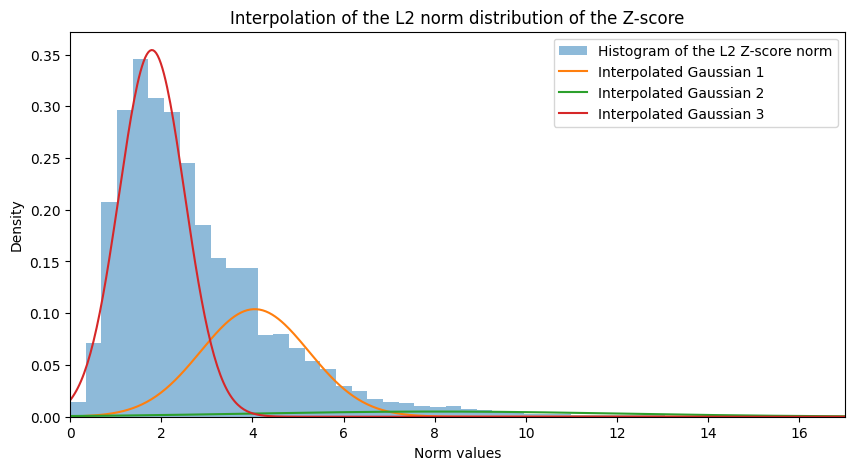

[0.30963485 0.05043931 0.63992584]


In [9]:
n = 3
radiusData = totalData["Radius"].loc[totalData["Well_down"]==0]

model = li.GaussianMixtureFit(radiusData,n,seed=mainSeed)

li.GaussianMixturePlot(radiusData,model,[
    "Histogram of the L2 Z-score norm",
    "Interpolated Gaussian",
    "Interpolation of the L2 norm distribution of the Z-score",
    "Norm values",
    "Density"
],
    figsize=(10,5))

print(model.weights_)

After that, we set out model to full covariance with the same # of states from the gaussians. Then, $params = ``st"$ set the model only to train state transition matrix and initial guess of probabilities. Also, we set the observation means and covariances as the GMM.

In [10]:
modelRadius = hmm.GaussianHMM(
    n_components=n,
    random_state=mainSeed,
    covariance_type="full",
    params="st",
    init_params="st",
    algorithm="viterbi"
    )

modelRadius.means_ = model.means_
modelRadius.covars__ = model.covariances_

With the model set, it is possible to train it. The training set is provided and its lengths as well. Next, a postprocessing is made on dataset, including the infered states into the original dataset. Also, stationary prob is print.

The most probable state is set as 1, meanwhile the less probable is set as $n=3$.

In [11]:
modelRadius = li.HMMTrainer(X_train["Radius"],trainLength,modelRadius)

totalData = li.PostProcessing(modelRadius, totalData, modelData,"Radius", "State Radius", totalLength)

print(modelRadius.get_stationary_distribution())


totalData["State Radius"] = totalData["State Radius"].map(li.StateConversion(modelRadius.get_stationary_distribution(),n))

AIC: 3019401.687754011 BIC: 3019564.7858059155
[0.16605607 0.02500672 0.80893721]


Next, we can plot the modified Z-score time series with the states being shown as coloured intervals. 

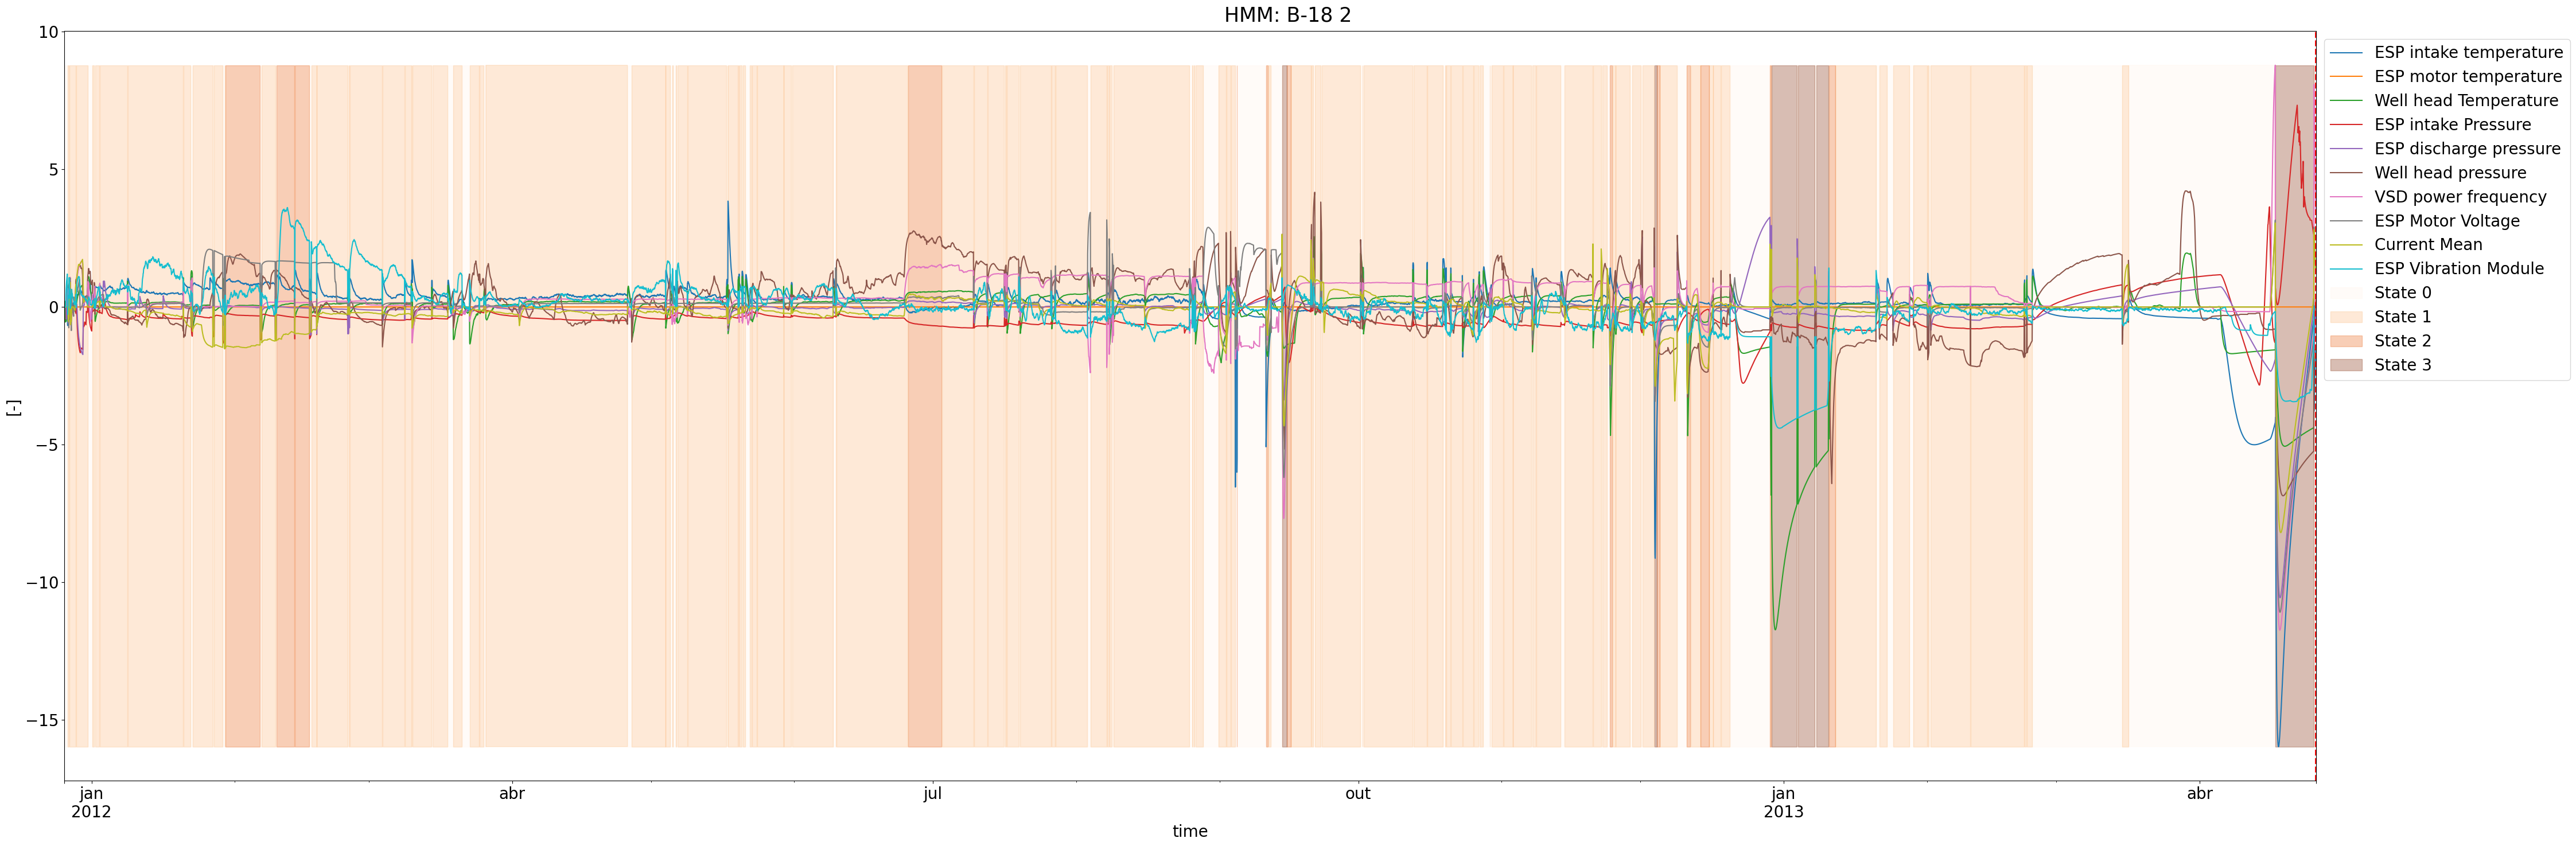

In [12]:
pump = pumpList[0]
pumpData = totalData.loc[totalData["Well Run"]==pump].copy()
fig,axs = li.HMMPicture(pumpData,pump,Headers=Headers,measures='[-]',states="State Radius", numberOfStates=3, figsize=(45,15))
plt.rcParams["font.size"]=20

fig.savefig("../imagens_gerais/pumps/"+pump+"markovrun.jpg")


It is possible to plot all pumps, if desired. 

In [13]:
# for pump in pumpList:
#     pumpData = totalData.loc[totalData["Well Run"]==pump].copy()
#     fig,axs = li.HMMPicture(pumpData,pump,Headers=[Headers],measures='[-]',states=["State Radius"], numberOfStates=n, figsize=(45,15))
#     plt.rcParams["font.size"]=20

#     fig.savefig("../imagens_gerais/pumps/"+pump+"markovrun.jpg")
#     plt.close()